# Clase 6 - Cálculo del Value at Risk

* Universidad de Cuenca - Curso. Riesgo Financiero Aplicado l
* Franco Mansilla Ibáñez (www.francomansilla.com)

# 1. Librería

In [ ]:
!pip install arch

In [ ]:
import numpy as np
import pandas as pd

import yfinance as yf

import scipy.stats as st
from scipy.stats import norm

from statsmodels.stats.diagnostic import acorr_ljungbox, het_white
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm
from arch import arch_model

import matplotlib.pyplot as plt
import cvxpy as cp

import warnings
warnings.filterwarnings('ignore')

# 2. Activos Financieros

* **JCI:** Johnson Controls International \\
* **TGT:** Target Corporation \\
* **CMCSA:** Comcast Corporation \\
* **CPB:** Campbell Soup Company \\
* **MO:** Altria Group \\
* **APA:** APA Corporation \\
* **AAPL:** Apple Inc. \\
* **JP:** J.P. Morgan Chase & Co \\
* **MSFT:** Microsoft Corporation \\





In [ ]:
assets = ['JCI', 'TGT', 'CMCSA',
          'CPB', 'MO', 'APA',
          'AAPL', 'JPM', 'MSFT'] # qué empresas son?
assets.sort()
start = '2022-01-01'
end = '2024-06-30'

In [ ]:
precios = yf.download(assets, start=start, end=end)
precios.head()

[*********************100%%**********************]  9 of 9 completed


Price        Adj Close                                              \
Ticker            AAPL        APA      CMCSA        CPB        JCI   
Date                                                                 
2022-01-03  179.273621  26.309448  46.967918  40.070473  74.611305   
2022-01-04  176.998337  27.622107  46.688847  40.418591  75.542191   
2022-01-05  172.290192  26.628237  46.716751  40.908234  74.310417   
2022-01-06  169.414124  27.772131  46.986515  41.601120  75.579811   
2022-01-07  169.581543  27.819010  46.558609  42.358681  74.536095   

Price                                                           Close  ...  \
Ticker             JPM         MO        MSFT         TGT        AAPL  ...   
Date                                                                   ...   
2022-01-03  149.576111  38.888073  326.940826  215.231277  182.009995  ...   
2022-01-04  155.246506  39.747387  321.334747  217.291275  179.699997  ...   
2022-01-05  152.408279  39.431225  308.999390  212.364014  174.919998  ...   
2022-01-06  154.027481  39.893311  306.557739  214.674545  172.000000  ...   
2022-01-07  155.553574  40.347290  306.713959  214.145630  172.169998  ...   

Price             Open     Volume                                        \
Ticker             TGT       AAPL       APA     CMCSA      CPB      JCI   
Date                                                                      
2022-01-03  231.070007  104487900   9319700  20706000  2815000  3598900   
2022-01-04  232.009995   99310400  13218200  24592800  2727500  2941500   
2022-01-05  234.809998   94537600   9212700  20727900  3807700  2944100   
2022-01-06  222.740005   96904000   7626800  18288200  5655500  2925200   
2022-01-07  230.179993   86709100   8355400  17894500  3677100  2759900   

Price                                              
Ticker           JPM        MO      MSFT      TGT  
Date                                               
2022-01-03  13120900  10308100  28865100  3018000  
2022-01-04  20195800  11647900  32674300  3327600  
2022-01-05  17539400  11506500  40054300  3885800  
2022-01-06  14047500  10134100  39646100  4193200  
2022-01-07  13913300   8098600  32720000  3052900  

[5 rows x 54 columns]

In [ ]:
precios = precios.loc[:, ('Adj Close', slice(None))]
precios.columns = assets
precios.head()

,AAPL,APA,CMCSA,CPB,JCI,JPM,MO,MSFT,TGT
Date,,,,,,,,,
2022-01-03,179.273621,26.309448,46.967918,40.070473,74.611305,149.576111,38.888073,326.940826,215.231277
2022-01-04,176.998337,27.622107,46.688847,40.418591,75.542191,155.246506,39.747387,321.334747,217.291275
2022-01-05,172.290192,26.628237,46.716751,40.908234,74.310417,152.408279,39.431225,308.999390,212.364014
2022-01-06,169.414124,27.772131,46.986515,41.601120,75.579811,154.027481,39.893311,306.557739,214.674545
2022-01-07,169.581543,27.819010,46.558609,42.358681,74.536095,155.553574,40.347290,306.713959,214.145630


* Cálculo de Retornos

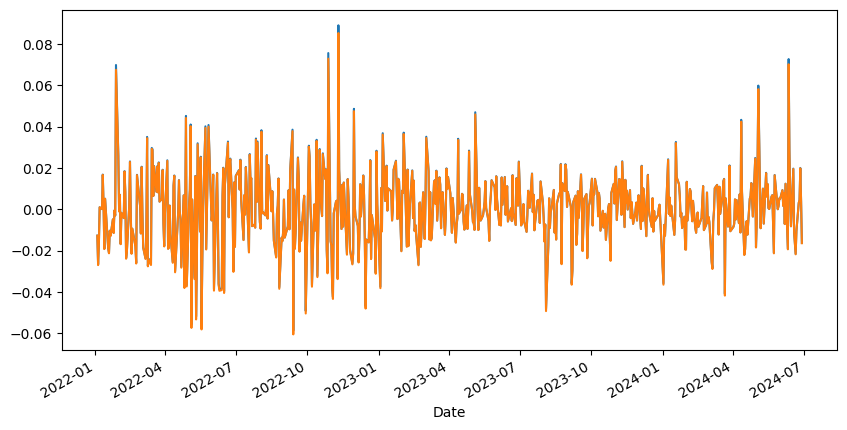

In [ ]:
# Cálculo de métricas
ret_cont = precios.pct_change().dropna()
ret_disc = np.log(precios).diff().dropna()

gra_cont = ret_cont['AAPL'].plot(figsize=(10,5))
gra_disc = ret_disc['AAPL'].plot(figsize=(10,5))

---
## 5.4. Optimización Sharpe

$$
\min y'\sum y $$
**s.t.** $$ \mu'y - r_f k = 1 \\ 1y' = k \\ y,t > 0 \\ x = \frac{y}{k}
$$

donde: \\
* $k$ representa transformación de schaible \\
* $r_f$ tasa libre de riesgo

---

# 3. Construcción de Portafolio

In [ ]:
n_obs, n_col = ret_cont.shape

prom_activos = ret_cont.mean().to_numpy().reshape(-1,1)
cov_var = ret_cont.cov().to_numpy()

R = ret_cont.to_numpy()
rf = 0.0001 # Risk free rate in same frequency of returns (daily in this case)

x = cp.Variable((n_col, 1))
k = cp.Variable(nonneg=True)

risk = cp.QuadForm(x, cov_var)
ret = prom_activos.T @ x - rf * k

# All constants in constraints must be multiplied by k
constraints = [cp.sum(x) == 1 * k,
               x >= 0 * k,
               ret == 1 # Only this constant is not multiply by k
               ]

objective = cp.Minimize(risk)
prob = cp.Problem(objective, constraints)

prob.solve()


weights = pd.DataFrame(x.value/k.value, index=assets, columns= ['weight'])
print(weights)

w = weights.to_numpy()
print('Ratio de Sharpe', ((prom_activos.T @ w - rf)/(w.T @ cov_var @ w)**0.5).item())

             weight
AAPL   2.799562e-18
APA    3.724115e-02
CMCSA  8.593166e-18
CPB    1.353559e-01
JCI    8.668233e-18
JPM    3.621063e-01
MO     1.234754e-01
MSFT   3.418213e-01
TGT    9.251011e-18
Ratio de Sharpe 0.03991334165641332


In [ ]:
prom_portafolio = weights.T @ prom_activos
print(prom_portafolio)
print((w.T @ cov_var @ w)**0.5)

               0
weight  0.000543
[[0.01110703]]


* Rentabilidad del portafolio

---

# 4. Cálculo del Value at Risk & Conditional Value at Risk


- **VaR (Value at Risk)**:
  $$
  \text{VaR}_{\alpha,t} = Z_\alpha \times \sigma \times \sqrt{t}
  $$
  Donde $Z_\alpha$ es el valor crítico de la distribución normal estándar para un nivel de confianza $\alpha$ y $\sigma$ es la desviación estándar de los retornos del portafolio.

- **CVaR (Conditional Value at Risk)**:
  $$
  \text{CVaR}_\alpha = \text{Media de las pérdidas que exceden el } \text{VaR}_\alpha
  $$
  Calcula el promedio de los retornos que están por debajo del umbral de VaR calculado para un nivel de confianza específico.
  
  ---


* Retorno del portafolio

In [ ]:
ret_prflio = (weights.T @ ret_cont.to_numpy().T).T
ret_prflio = ret_prflio.rename(columns={'weight': 'ret_prflio'}) # Rename the column
ret_prflio.head()

,ret_prflio
0,0.013629
1,-0.020424
2,0.006485
3,0.007695
4,0.002164


       ret_prflio
count  624.000000
mean     0.000543
std      0.011107
min     -0.041598
25%     -0.006147
50%      0.000780
75%      0.007395
max      0.041364


<Axes: >

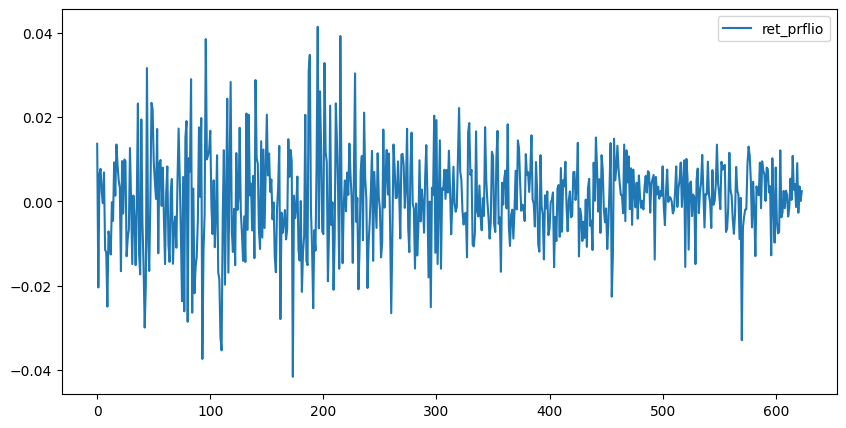

In [ ]:
print(ret_prflio.describe())

ret_prflio.plot(figsize=(10,5))

## 4.1. VaR Parámetrico



In [ ]:
# Calcular la desviación estándar de los retornos del portafolio
std_dev = ret_prflio['ret_prflio'].std()

# Definir los niveles de confianza para el VaR
confidence_levels = [0.01, 0.05, 0.10]

# Calcular el VaR en diferentes niveles de confianza usando el puntaje Z para la distribución normal
vars = {}
for alpha in confidence_levels:
    z_score = norm.ppf(1 - alpha)
    var = z_score * std_dev
    vars[f'VaR {alpha*100}%'] = var

# Mostrar los resultados
vars


{'VaR 1.0%': 0.025838807436057796,
 'VaR 5.0%': 0.018269432788431794,
 'VaR 10.0%': 0.014234227172553984}

In [ ]:
# Definir los niveles de confianza para el VaR y CVaR
confidence_levels = [0.01, 0.05, 0.10]
t = 1

# Calcular el VaR en diferentes niveles de confianza
vars = {}
cvars = {}
for alpha in confidence_levels:
    z_score = norm.ppf(1 - alpha)
    var = z_score * std_dev * t
    vars[f'VaR {alpha*100}%'] = var

    # Calcular el CVaR (solo considerando los retornos que exceden el umbral del VaR)
    var_threshold = var
    losses_below_var = ret_prflio[ret_prflio['ret_prflio'] <= -var_threshold]['ret_prflio']

    # CVaR es el promedio de las pérdidas que exceden el VaR
    if not losses_below_var.empty:
        cvar = losses_below_var.mean()
    else:
        cvar = 0  # No hay valores que superen el umbral de VaR

    cvars[f'CVaR {alpha*100}%'] = cvar

# Mostrar los resultados de VaR y CVaR
print("VaR:", vars)
print("CVaR:", cvars)


VaR: {'VaR 1.0%': 0.025838807436057796, 'VaR 5.0%': 0.018269432788431794, 'VaR 10.0%': 0.014234227172553984}
CVaR: {'CVaR 1.0%': -0.031356986546113824, 'CVaR 5.0%': -0.025756556453449788, 'CVaR 10.0%': -0.020627287898053653}


## 4.2. VaR Simulación Historica

In [ ]:
t = 1

vars = {}
cvars = {}

for alpha in confidence_levels:

    var = np.percentile(ret_prflio['ret_prflio'], 100 * (1 - alpha)) * t
    vars[f'VaR {alpha*100}%'] = var

    # Calcular el CVaR (solo considerando los retornos que exceden el umbral del VaR)
    var_threshold = var
    losses_below_var = ret_prflio[ret_prflio['ret_prflio'] <= -var_threshold]['ret_prflio']

    # CVaR es el promedio de las pérdidas que exceden el VaR
    if not losses_below_var.empty:
        cvar = losses_below_var.mean()
    else:
        cvar = 0  # No hay valores que superen el umbral de VaR

    cvars[f'CVaR {alpha*100}%'] = cvar

# Mostrar los resultados de VaR y CVaR
print("VaR:", vars)
print("CVaR:", cvars)


VaR: {'VaR 1.0%': 0.03071761832461196, 'VaR 5.0%': 0.017565864184273538, 'VaR 10.0%': 0.01307328528646559}
CVaR: {'CVaR 1.0%': -0.03590257030629106, 'CVaR 5.0%': -0.025471031917246527, 'CVaR 10.0%': -0.019633535514559573}


## 4.3. VaR Montecarlo

* Ajuste de Distribución

In [ ]:
def get_best_distribution(data):
    # Añadiendo 'logistic' y 'laplace' a la lista de distribuciones
    dist_names = ["norm", "t", "lognorm", "expon", "weibull_min", "logistic", "laplace"]
    dist_results = []
    params = {}

    for dist_name in dist_names:
        dist = getattr(st, dist_name)
        param = dist.fit(data)
        params[dist_name] = param

        # Aplicar la prueba de Kolmogorov-Smirnov
        D, p = st.kstest(data, dist_name, args=param)
        dist_results.append((dist_name, p))

    # Seleccionar la distribución que mejor se ajusta
    best_dist, best_p = max(dist_results, key=lambda item: item[1])

    return best_dist, best_p, params[best_dist]

In [ ]:
dist, pvalue, param = get_best_distribution(ret_prflio['ret_prflio'])
print(dist, pvalue, param)

t 0.7874821394230185 (5.879570194251691, 0.0006324489490646852, 0.009104241505361403)


* Simulación de Montecarlo

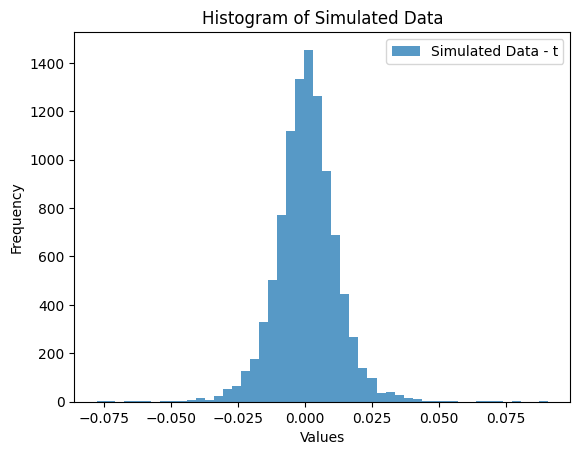

Mean of simulated data: 0.0007710818550902426
Standard deviation of simulated data: 0.011316110434519109


In [ ]:
# Suponemos que tienes los siguientes resultados de tu función
dist, pvalue, param = get_best_distribution(ret_prflio['ret_prflio'])

# Obtener la distribución desde scipy.stats
distribution = getattr(st, dist)

# Generar datos simulados utilizando los parámetros ajustados
num_simulations = 10000  # Puedes ajustar esto a cuantas simulaciones necesites
simulated_data = distribution.rvs(*param[:-2], loc=param[-2], scale=param[-1], size=num_simulations)

# Visualizar los resultados de la simulación
plt.hist(simulated_data, bins=50, alpha=0.75, label=f'Simulated Data - {dist}')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram of Simulated Data')
plt.legend()
plt.show()

# Realizar análisis adicionales si es necesario
# Por ejemplo, calcular estadísticas descriptivas o aplicar pruebas adicionales
print(f"Mean of simulated data: {np.mean(simulated_data)}")
print(f"Standard deviation of simulated data: {np.std(simulated_data)}")


* Cálculo de VaR

In [ ]:
t = 1
vars = {}
cvars = {}
confidence_levels = [0.01, 0.05, 0.10]  # Definir tus niveles de confianza

for alpha in confidence_levels:
    # Calcular el VaR usando percentiles de los datos simulados
    var = np.percentile(simulated_data, 100 * (1 - alpha)) * t
    vars[f'VaR {alpha*100}%'] = var

    # Calcular el CVaR (solo considerando los retornos que exceden el umbral del VaR)
    var_threshold = var
    losses_below_var = simulated_data[simulated_data <= -var_threshold]

    # CVaR es el promedio de las pérdidas que exceden el VaR
    cvar = losses_below_var.mean() if not losses_below_var.size == 0 else 0
    cvars[f'CVaR {alpha*100}%'] = cvar

# Mostrar los resultados de VaR y CVaR
print("VaR:", vars)
print("CVaR:", cvars)


VaR: {'VaR 1.0%': 0.031243230791096536, 'VaR 5.0%': 0.01834951354951775, 'VaR 10.0%': 0.013817883864591497}
CVaR: {'CVaR 1.0%': -0.04068401598518123, 'CVaR 5.0%': -0.025606972120421075, 'CVaR 10.0%': -0.020939370525439056}


## 4.4.  VaR Volatilidad GARCH

* Verificar si serie de retornos se puede modelar con GARCH

In [ ]:
# Crear la variable 'y' como un array 1D
y = ret_prflio['ret_prflio'].to_numpy()

# Crear la matriz de características 'X' con la constante
X = ret_prflio['ret_prflio'].shift(1)  # Asumiendo que 'ret_portaf' es la característica y necesita ser desplazada
X = sm.add_constant(X)  # Agregar la constante

# Eliminar la primera fila que ahora contiene un NaN en la columna 'ret_portaf'
X.dropna(inplace=True)
y = y[1:]  # Asegurarte de que 'y' tenga la misma longitud que 'X' después de eliminar NaN

# Crear y ajustar el modelo
model = sm.OLS(y, X)
results = model.fit()

# Mostrar los resultados
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.6584
Date:                Thu, 22 Aug 2024   Prob (F-statistic):              0.417
Time:                        21:46:46   Log-Likelihood:                 1920.6
No. Observations:                 623   AIC:                            -3837.
Df Residuals:                     621   BIC:                            -3828.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000      1.133      0.2

* Cálculo de residuos

In [ ]:
# Ajustar el modelo
results = model.fit()

# Obtener los residuales
residuales = results.resid
residuales.shape

(623,)

* Test de White ($H_0: Homocedasticidad$)

In [ ]:
white_test = het_white(residuales, X)
white_stat, white_pvalue, _, _ = white_test

# Mostrar los resultados del test de White
print(results.summary())
print(f"White statistic: {white_stat}")
print(f"p-value: {white_pvalue}")


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.6584
Date:                Thu, 22 Aug 2024   Prob (F-statistic):              0.417
Time:                        21:46:46   Log-Likelihood:                 1920.6
No. Observations:                 623   AIC:                            -3837.
Df Residuals:                     621   BIC:                            -3828.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000      1.133      0.2

### 4.5. Modelos ARCH/GARCH

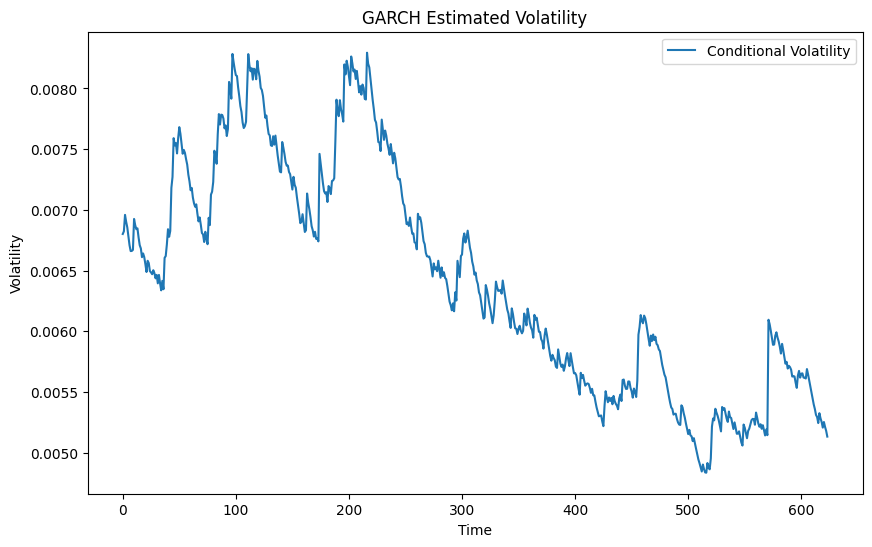

In [ ]:
# Ajustar el modelo GARCH
am = arch_model(ret_prflio['ret_prflio'], mean='Zero', vol='Garch', p=1, o=0, q=1, dist='Normal', rescale=False)
res = am.fit(update_freq=5, disp="off")

# Volatilidad condicional estimada por el modelo GARCH
volatility = (res.conditional_volatility ** 0.5)* np.sqrt(1/252)

# Graficar la volatilidad condicional
plt.figure(figsize=(10, 6))
plt.plot(volatility, label='Conditional Volatility')
plt.title('GARCH Estimated Volatility')
plt.xlabel('Time')
plt.ylabel('Volatility')
plt.legend()
plt.show()

* **Validación 1**: Errores son Ruido Blanco


$H_0$ = Ruido Blanco

In [ ]:
# Calcular residuos estandarizados
std_resid = res.resid / res.conditional_volatility

# Aplicar prueba de Ljung-Box en los residuos estandarizados
lb_test = acorr_ljungbox(std_resid, lags=[10], return_df=True)

lb_test

,lb_stat,lb_pvalue
10,8.242022,0.60521


Si la columna lb_pvalue muestra un valor **muy bajo**, es mucho menor que 0.05, por lo que rechazarías la hipótesis nula y concluirías que hay autocorrelaciones significativas en los residuos a los primeros 10 lags. Esto implica que el modelo GARCH podría no estar capturando toda la autocorrelación en los datos, y podrías considerar ajustar el modelo o usar un enfoque diferente.



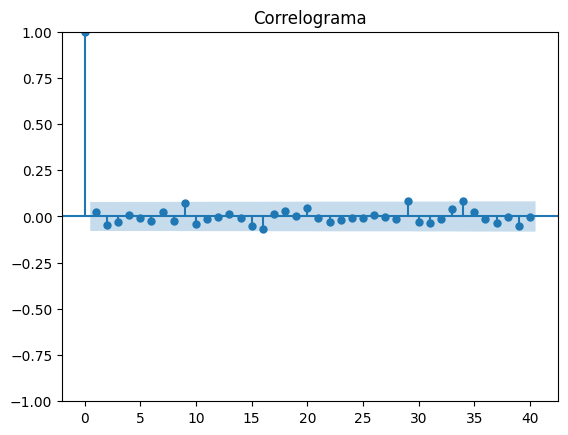

In [ ]:
plot_acf(std_resid, lags=40, alpha=0.05)
#plot_acf(std_resid**2, lags=40, alpha=0.05)

plt.title('Correlograma')
plt.show()


* Cálculo Volatilidad

In [ ]:
# Parámetros del modelo
omega = res.params['omega']
alpha = res.params['alpha[1]']
beta = res.params['beta[1]']

# Último valor de la serie temporal
T = len(ret_prflio['ret_prflio'])

# Calcular sigma^2 para t+1
sigma2 = omega + alpha * ret_prflio['ret_prflio'].iloc[-1]**2 + beta * res.conditional_volatility.iloc[-1]**2
volatilidad_dinamica =  np.sqrt(sigma2)
print('Validación 2:', alpha + beta)

Validación 2: 0.9941607145635667


* Cálculo VaR y CVaR

In [ ]:
t = 1
vars = {}
cvars = {}
confidence_levels = [0.01, 0.05, 0.10]  # Definir tus niveles de confianza

for alpha in confidence_levels:

    z_score = norm.ppf(1 - alpha)
    var = z_score * volatilidad_dinamica * t
    vars[f'VaR {alpha*100}%'] = var

    # Calcular el CVaR (solo considerando los retornos que exceden el umbral del VaR)
    var_threshold = var
    losses_below_var = simulated_data[simulated_data <= -var_threshold]

    # CVaR es el promedio de las pérdidas que exceden el VaR
    cvar = losses_below_var.mean() if not losses_below_var.size == 0 else 0
    cvars[f'CVaR {alpha*100}%'] = cvar

# Mostrar los resultados de VaR y CVaR
print("VaR:", vars)
print("CVaR:", cvars)


VaR: {'VaR 1.0%': 0.015207441844332344, 'VaR 5.0%': 0.010752482959848379, 'VaR 10.0%': 0.00837756086310522}
CVaR: {'CVaR 1.0%': -0.02240113804147925, 'CVaR 5.0%': -0.01778568259166208, 'CVaR 10.0%': -0.015555814186905208}
